In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
path = "/content/drive/My Drive/Colab Notebooks/datata/"

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
fall_classes = [
    "diamjatuh",
    "jalanjatuh"
]

In [5]:
peak_info = []

In [6]:
for cls in fall_classes:

    folder = os.path.join(path, cls)

    files = os.listdir(folder)

    print("\nPROCESS :", cls)

    for f in files:

        fp = os.path.join(folder, f)

        try:

            df = pd.read_csv(fp)

            needed = [
                "ax",
                "ay",
                "az"
            ]

            if not all(col in df.columns for col in needed):
                continue

            df["acc_mag"] = np.sqrt(
                df["ax"]**2 +
                df["ay"]**2 +
                df["az"]**2
            )

            peak_acc = df["acc_mag"].max()

            mean_acc = df["acc_mag"].mean()

            std_acc = df["acc_mag"].std()

            peak_info.append([
                cls,
                f,
                len(df),
                peak_acc,
                mean_acc,
                std_acc
            ])

        except Exception as e:

            print("ERROR :", f)
            print(e)


PROCESS : diamjatuh

PROCESS : jalanjatuh


In [7]:
peak_df = pd.DataFrame(
    peak_info,
    columns=[
        "class",
        "file",
        "samples",
        "peak_acc",
        "mean_acc",
        "std_acc"
    ]
)

In [8]:
peak_df.head()

,class,file,samples,peak_acc,mean_acc,std_acc
0,diamjatuh,diamjatuh_01.csv,3815,2.122434,1.021444,0.153081
1,diamjatuh,diamjatuh_011.csv,2611,1.090669,0.999343,0.015914
2,diamjatuh,diamjatuh_012.csv,2278,3.433603,1.007000,0.156847
3,diamjatuh,diamjatuh_02.csv,2364,1.784862,1.017864,0.092318
4,diamjatuh,diamjatuh_021.csv,2231,3.463986,1.005861,0.145131


In [9]:
peak_df.sort_values(
    by="peak_acc"
)

,class,file,samples,peak_acc,mean_acc,std_acc
62,diamjatuh,diamjatuh_tidurmenjangkau_kanan_langsung1.csv,717,1.012024,1.002437,0.002299
1,diamjatuh,diamjatuh_011.csv,2611,1.090669,0.999343,0.015914
113,jalanjatuh,jalanjatuh_b5cepat_tersandung_tangan.csv,949,1.263979,1.008849,0.053572
12,diamjatuh,diamjatuh_berdiri_kanan_tangan (2).csv,2229,1.553541,1.010774,0.106317
106,jalanjatuh,jalanjatuh_jnormal_tersandung_langsung.csv,1988,1.709715,1.088992,0.232878
...,...,...,...,...,...,...
118,jalanjatuh,jalanmundur_depan_langsung (2).csv,2301,3.464102,1.082917,0.255126
129,jalanjatuh,jalannormal_tersandung_langsung (2).csv,2750,3.464102,1.091262,0.315461
132,jalanjatuh,jalannormal_tersandung_tangan.csv,2412,3.464102,1.086452,0.282990
131,jalanjatuh,jalannormal_tersandung_langsung (4).csv,2295,3.464102,1.060362,0.210662


In [10]:
peak_df.sort_values(
    by="peak_acc",
    ascending=False
)

,class,file,samples,peak_acc,mean_acc,std_acc
5,diamjatuh,diamjatuh_03.csv,2364,3.464102,1.018804,0.200251
50,diamjatuh,diamjatuh_dudukmenjangkau_kanan_langsung.csv,2363,3.464102,1.017541,0.170262
51,diamjatuh,diamjatuh_dudukmenjangkau_kiri_langsung.csv,2340,3.464102,1.023405,0.208392
55,diamjatuh,diamjatuh_dudukmenjangkau_depan_langsung.csv,2099,3.464102,1.023300,0.197176
52,diamjatuh,diamjatuh_dudukmenjangkau_kiri_tangan.csv,2344,3.464102,1.008883,0.196388
...,...,...,...,...,...,...
106,jalanjatuh,jalanjatuh_jnormal_tersandung_langsung.csv,1988,1.709715,1.088992,0.232878
12,diamjatuh,diamjatuh_berdiri_kanan_tangan (2).csv,2229,1.553541,1.010774,0.106317
113,jalanjatuh,jalanjatuh_b5cepat_tersandung_tangan.csv,949,1.263979,1.008849,0.053572
1,diamjatuh,diamjatuh_011.csv,2611,1.090669,0.999343,0.015914


In [ ]:
peak_df.describe()

,samples,peak_acc,mean_acc,std_acc
count,139.000000,139.000000,139.000000,139.000000
mean,2643.410072,3.255028,1.057427,0.247317
std,736.644083,0.519272,0.041503,0.082284
min,717.000000,1.012024,0.996705,0.002299
25%,2349.500000,3.463986,1.022013,0.188034
50%,2520.000000,3.464044,1.054159,0.248073
75%,2663.000000,3.464102,1.082269,0.303251
max,5876.000000,3.464102,1.196768,0.453299


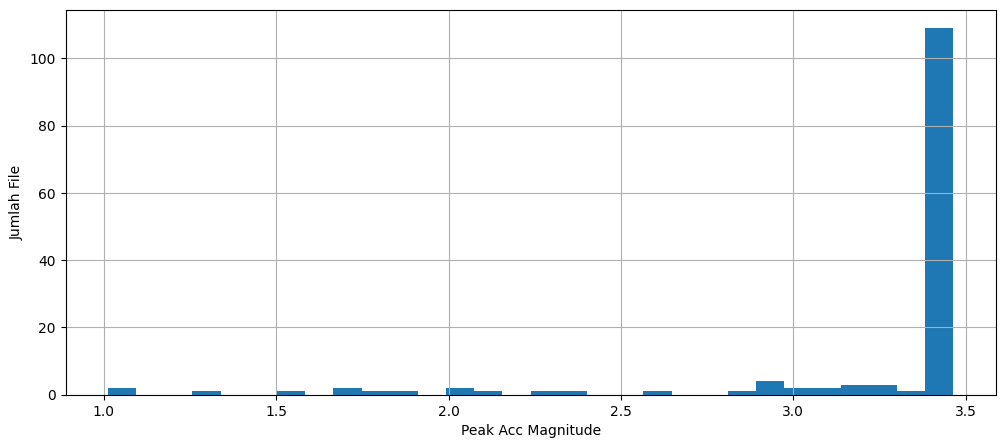

In [11]:
plt.figure(figsize=(12,5))

plt.hist(
    peak_df["peak_acc"],
    bins=30
)

plt.xlabel("Peak Acc Magnitude")

plt.ylabel("Jumlah File")

plt.grid()

plt.show()

In [ ]:
peak_df.groupby("class")["peak_acc"].mean()

,peak_acc
class,
diamjatuh,3.208853
jalanjatuh,3.299251


In [ ]:
peak_df.groupby("class")["peak_acc"].max()

,peak_acc
class,
diamjatuh,3.464102
jalanjatuh,3.464102


In [ ]:
peak_df.groupby("class")["peak_acc"].min()

,peak_acc
class,
diamjatuh,1.012024
jalanjatuh,1.263979


In [ ]:
suspect_df = peak_df[
    peak_df["peak_acc"] < 1.8
]

suspect_df

,class,file,samples,peak_acc,mean_acc,std_acc
1,diamjatuh,diamjatuh_011.csv,2611,1.090669,0.999343,0.015914
3,diamjatuh,diamjatuh_02.csv,2364,1.784862,1.017864,0.092318
12,diamjatuh,diamjatuh_berdiri_kanan_tangan (2).csv,2229,1.553541,1.010774,0.106317
57,diamjatuh,diamjatuh_tidurmenjangkau_kiri_tangan.csv,4141,1.747118,1.008249,0.084295
62,diamjatuh,diamjatuh_tidurmenjangkau_kanan_langsung1.csv,717,1.012024,1.002437,0.002299
106,jalanjatuh,jalanjatuh_jnormal_tersandung_langsung.csv,1988,1.709715,1.088992,0.232878
113,jalanjatuh,jalanjatuh_b5cepat_tersandung_tangan.csv,949,1.263979,1.008849,0.053572


In [ ]:
print(
    "Jumlah file mencurigakan :",
    len(suspect_df)
)

Jumlah file mencurigakan : 7


In [ ]:
suspect_df.sort_values(
    by="peak_acc"
)

,class,file,samples,peak_acc,mean_acc,std_acc
62,diamjatuh,diamjatuh_tidurmenjangkau_kanan_langsung1.csv,717,1.012024,1.002437,0.002299
1,diamjatuh,diamjatuh_011.csv,2611,1.090669,0.999343,0.015914
113,jalanjatuh,jalanjatuh_b5cepat_tersandung_tangan.csv,949,1.263979,1.008849,0.053572
12,diamjatuh,diamjatuh_berdiri_kanan_tangan (2).csv,2229,1.553541,1.010774,0.106317
106,jalanjatuh,jalanjatuh_jnormal_tersandung_langsung.csv,1988,1.709715,1.088992,0.232878
57,diamjatuh,diamjatuh_tidurmenjangkau_kiri_tangan.csv,4141,1.747118,1.008249,0.084295
3,diamjatuh,diamjatuh_02.csv,2364,1.784862,1.017864,0.092318


In [ ]:
target = suspect_df.iloc[0]

target

,1
class,diamjatuh
file,diamjatuh_011.csv
samples,2611
peak_acc,1.090669
mean_acc,0.999343
std_acc,0.015914


In [ ]:
target_class = target["class"]

target_file = target["file"]

target_path = os.path.join(
    path,
    target_class,
    target_file
)

print(target_path)

/content/drive/My Drive/Colab Notebooks/datata/diamjatuh/diamjatuh_011.csv


In [ ]:
df["acc_mag"] = np.sqrt(
    df["ax"]**2 +
    df["ay"]**2 +
    df["az"]**2
)

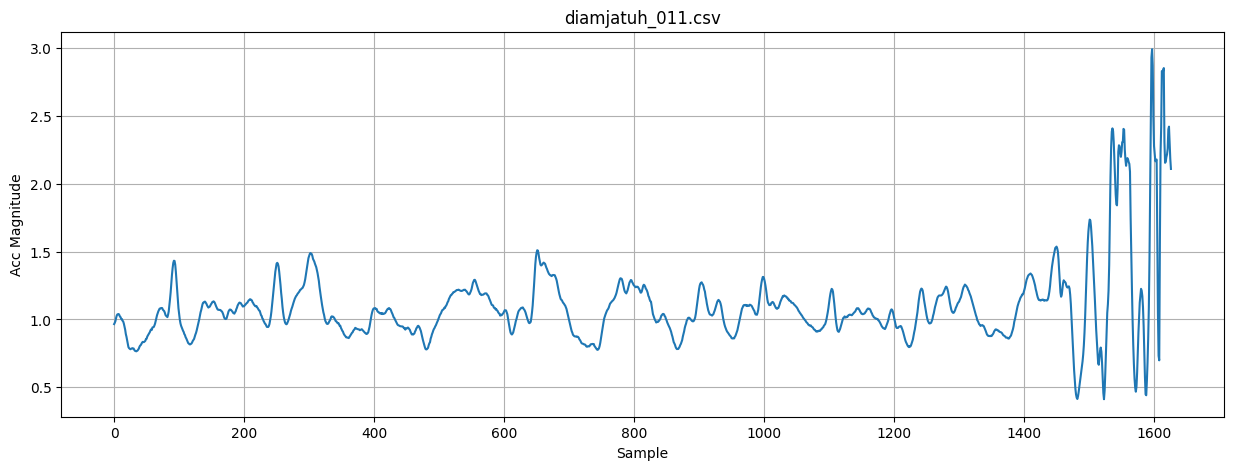

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(df["acc_mag"])

plt.title(target_file)

plt.xlabel("Sample")

plt.ylabel("Acc Magnitude")

plt.grid()

plt.show()

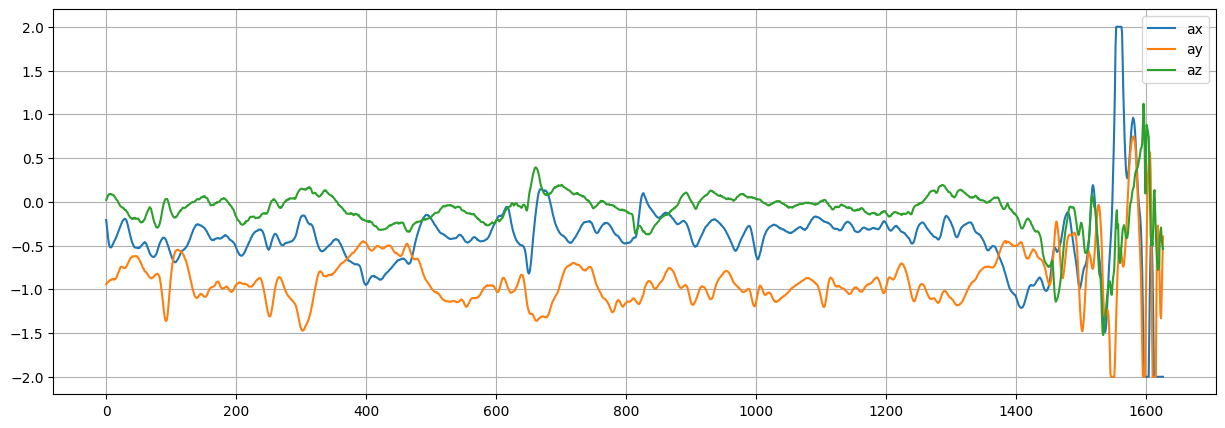

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(df["ax"], label="ax")
plt.plot(df["ay"], label="ay")
plt.plot(df["az"], label="az")

plt.legend()

plt.grid()

plt.show()

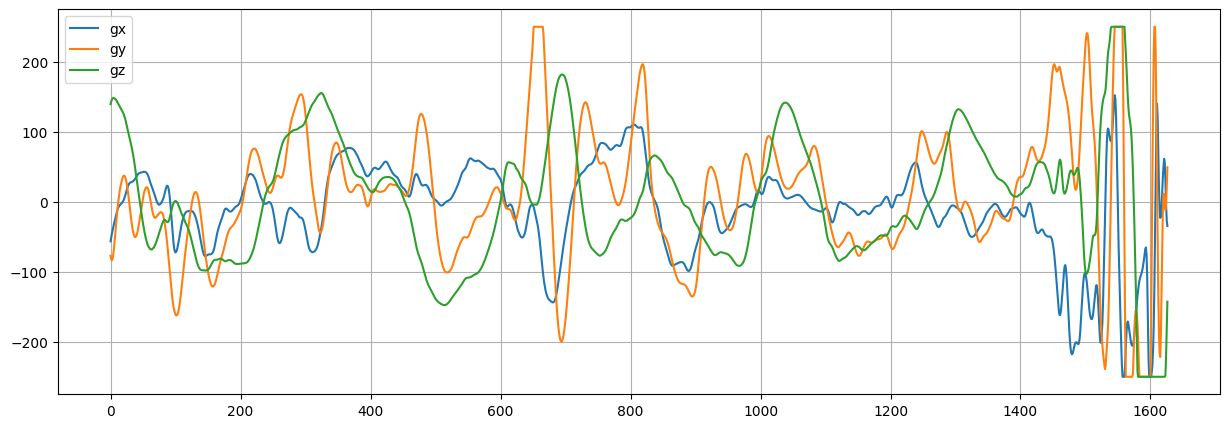

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(df["gx"], label="gx")
plt.plot(df["gy"], label="gy")
plt.plot(df["gz"], label="gz")

plt.legend()

plt.grid()

plt.show()

In [ ]:
peak_df.to_csv(
    "fall_peak_analysis.csv",
    index=False
)

In [ ]:
from google.colab import files

files.download(
    "fall_peak_analysis.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
path = "/content/drive/My Drive/Colab Notebooks/datata/"

In [ ]:
fall_classes = [
    "diamjatuh",
    "jalanjatuh"
]

In [ ]:
peak_position_info = []

In [ ]:
for cls in fall_classes:

    folder = os.path.join(path, cls)

    files = os.listdir(folder)

    print("\nPROCESS :", cls)

    for f in files:

        fp = os.path.join(folder, f)

        try:

            df = pd.read_csv(fp)

            needed = [
                "ax",
                "ay",
                "az"
            ]

            if not all(col in df.columns for col in needed):
                continue

            df["acc_mag"] = np.sqrt(
                df["ax"]**2 +
                df["ay"]**2 +
                df["az"]**2
            )

            peak_idx = df["acc_mag"].idxmax()

            peak_value = df["acc_mag"].max()

            total_samples = len(df)

            peak_ratio = peak_idx / total_samples

            peak_position_info.append([
                cls,
                f,
                total_samples,
                peak_idx,
                peak_ratio,
                peak_value
            ])

        except Exception as e:

            print("ERROR :", f)
            print(e)


PROCESS : diamjatuh

PROCESS : jalanjatuh


In [ ]:
peak_df = pd.DataFrame(
    peak_position_info,
    columns=[
        "class",
        "file",
        "samples",
        "peak_index",
        "peak_ratio",
        "peak_acc"
    ]
)

In [ ]:
peak_df.head()

,class,file,samples,peak_index,peak_ratio,peak_acc
0,diamjatuh,diamjatuh_01.csv,3815,1981,0.519266,2.122434
1,diamjatuh,diamjatuh_011.csv,2611,2016,0.772118,1.090669
2,diamjatuh,diamjatuh_012.csv,2278,632,0.277436,3.433603
3,diamjatuh,diamjatuh_02.csv,2364,690,0.291878,1.784862
4,diamjatuh,diamjatuh_021.csv,2231,779,0.349171,3.463986


In [ ]:
peak_df.sort_values(
    by="peak_ratio"
)

,class,file,samples,peak_index,peak_ratio,peak_acc
117,jalanjatuh,jalanmundur_depan_langsung.csv,2186,46,0.021043,3.464102
15,diamjatuh,diamjatuh_berdiri_kiri_tangan.csv,3340,139,0.041617,2.939401
14,diamjatuh,diamjatuh_berdiri_kiri_langsung.csv,2594,324,0.124904,3.199768
18,diamjatuh,diamjatuh_berdiri_belakang_langsung.csv,2585,327,0.126499,3.464044
17,diamjatuh,diamjatuh_berdiri_belakang_tangan_2.csv,2754,531,0.192810,3.464044
...,...,...,...,...,...,...
7,diamjatuh,diamjatuh_05.csv,826,674,0.815981,1.834903
128,jalanjatuh,jalannormal_tersandung_langsung.csv,1893,1572,0.830428,2.812171
106,jalanjatuh,jalanjatuh_jnormal_tersandung_langsung.csv,1988,1810,0.910463,1.709715
62,diamjatuh,diamjatuh_tidurmenjangkau_kanan_langsung1.csv,717,695,0.969317,1.012024


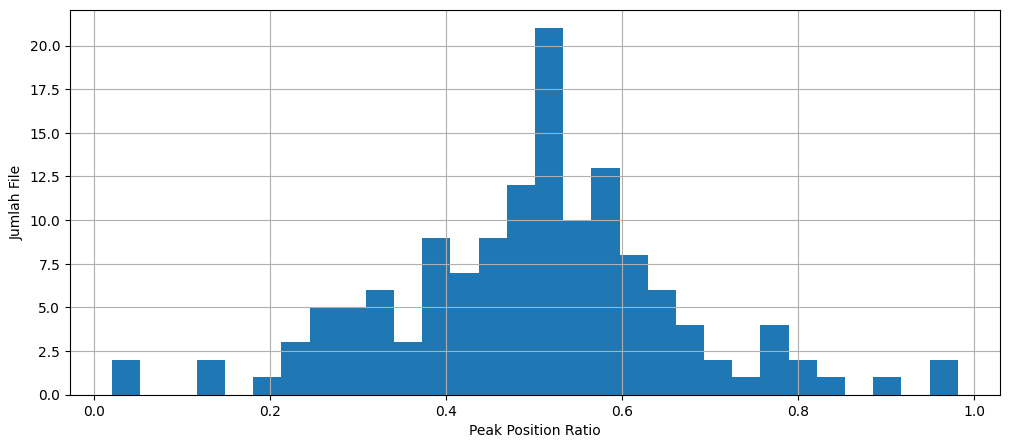

In [ ]:
plt.figure(figsize=(12,5))

plt.hist(
    peak_df["peak_ratio"],
    bins=30
)

plt.xlabel("Peak Position Ratio")

plt.ylabel("Jumlah File")

plt.grid()

plt.show()

In [ ]:
bad_position_df = peak_df[
    (peak_df["peak_ratio"] < 0.25) |
    (peak_df["peak_ratio"] > 0.75)
]

bad_position_df

,class,file,samples,peak_index,peak_ratio,peak_acc
1,diamjatuh,diamjatuh_011.csv,2611,2016,0.772118,1.090669
6,diamjatuh,diamjatuh_04.csv,2379,592,0.248844,3.464044
7,diamjatuh,diamjatuh_05.csv,826,674,0.815981,1.834903
8,diamjatuh,diamjatuh_berdiri_depan_tangan.csv,3423,842,0.245983,2.357747
9,diamjatuh,diamjatuh_berdiri_depan_tangan (2).csv,2669,595,0.222930,3.463986
14,diamjatuh,diamjatuh_berdiri_kiri_langsung.csv,2594,324,0.124904,3.199768
15,diamjatuh,diamjatuh_berdiri_kiri_tangan.csv,3340,139,0.041617,2.939401
17,diamjatuh,diamjatuh_berdiri_belakang_tangan_2.csv,2754,531,0.192810,3.464044
18,diamjatuh,diamjatuh_berdiri_belakang_langsung.csv,2585,327,0.126499,3.464044
20,diamjatuh,diamjatuh_duduk_belakang_tangan.csv,2399,576,0.240100,3.464044


In [ ]:
print(
    "Jumlah file peak tidak di tengah :",
    len(bad_position_df)
)

Jumlah file peak tidak di tengah : 20


In [ ]:
bad_position_df.sort_values(
    by="peak_ratio"
)

,class,file,samples,peak_index,peak_ratio,peak_acc
117,jalanjatuh,jalanmundur_depan_langsung.csv,2186,46,0.021043,3.464102
15,diamjatuh,diamjatuh_berdiri_kiri_tangan.csv,3340,139,0.041617,2.939401
14,diamjatuh,diamjatuh_berdiri_kiri_langsung.csv,2594,324,0.124904,3.199768
18,diamjatuh,diamjatuh_berdiri_belakang_langsung.csv,2585,327,0.126499,3.464044
17,diamjatuh,diamjatuh_berdiri_belakang_tangan_2.csv,2754,531,0.192810,3.464044
9,diamjatuh,diamjatuh_berdiri_depan_tangan (2).csv,2669,595,0.222930,3.463986
122,jalanjatuh,jalanmundur_sampingkanan_langsung.csv,2275,542,0.238242,3.464102
20,diamjatuh,diamjatuh_duduk_belakang_tangan.csv,2399,576,0.240100,3.464044
8,diamjatuh,diamjatuh_berdiri_depan_tangan.csv,3423,842,0.245983,2.357747
6,diamjatuh,diamjatuh_04.csv,2379,592,0.248844,3.464044


In [ ]:
target = bad_position_df.iloc[0]

target

,1
class,diamjatuh
file,diamjatuh_011.csv
samples,2611
peak_index,2016
peak_ratio,0.772118
peak_acc,1.090669


In [ ]:
target = bad_position_df.iloc[0]

target

,1
class,diamjatuh
file,diamjatuh_011.csv
samples,2611
peak_index,2016
peak_ratio,0.772118
peak_acc,1.090669


In [ ]:
target_class = target["class"]

target_file = target["file"]

target_path = os.path.join(
    path,
    target_class,
    target_file
)

print(target_path)

/content/drive/My Drive/Colab Notebooks/datata/diamjatuh/diamjatuh_011.csv


In [ ]:
df = pd.read_csv(target_path)

In [ ]:
df["acc_mag"] = np.sqrt(
    df["ax"]**2 +
    df["ay"]**2 +
    df["az"]**2
)

In [ ]:
peak_idx = df["acc_mag"].idxmax()

peak_value = df["acc_mag"].max()

print("Peak Index :", peak_idx)

print("Peak Value :", peak_value)

Peak Index : 2016
Peak Value : 1.090668570189863


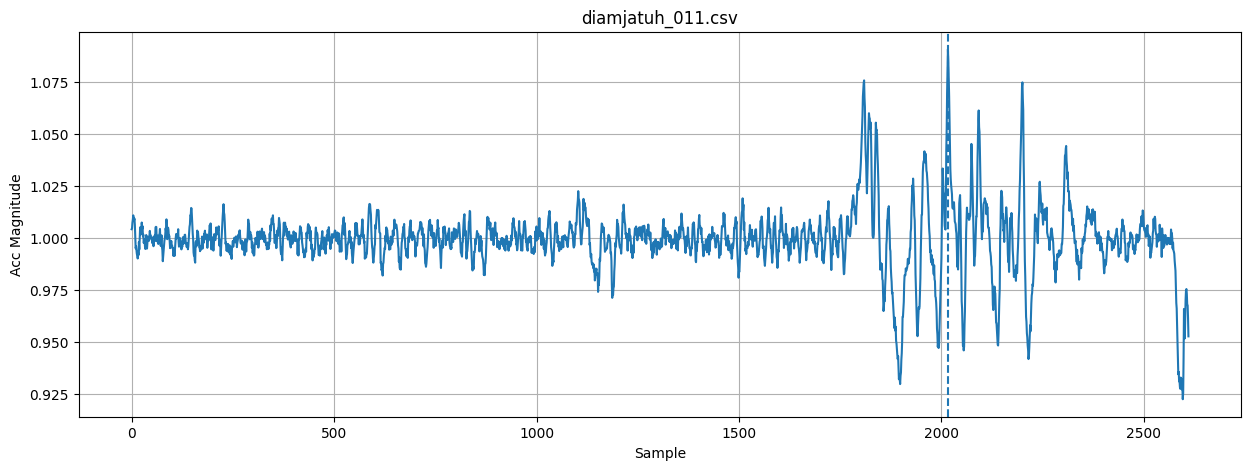

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(df["acc_mag"])

plt.axvline(
    peak_idx,
    linestyle="--"
)

plt.title(target_file)

plt.xlabel("Sample")

plt.ylabel("Acc Magnitude")

plt.grid()

plt.show()

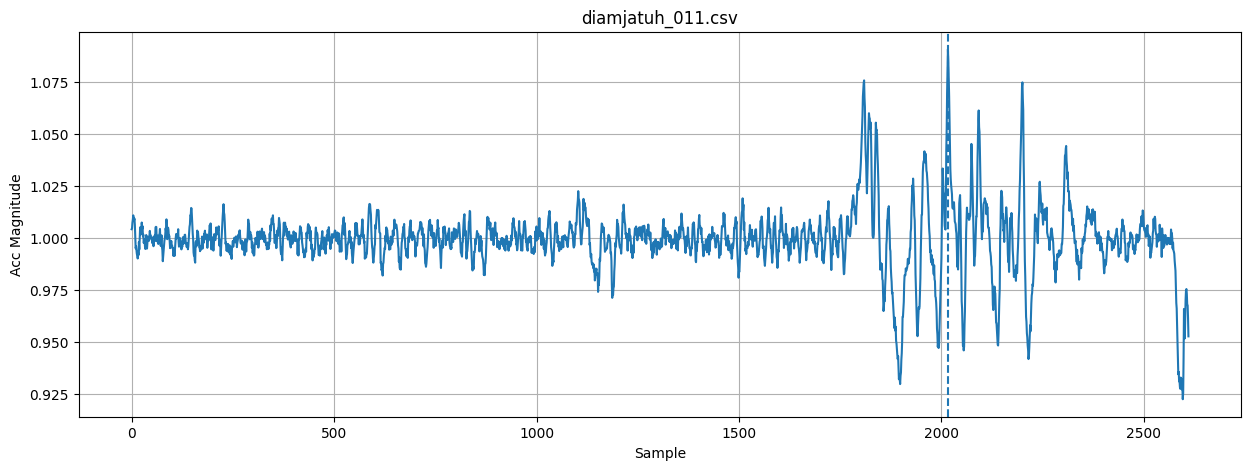

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(df["acc_mag"])

plt.axvline(
    peak_idx,
    linestyle="--"
)

plt.title(target_file)

plt.xlabel("Sample")

plt.ylabel("Acc Magnitude")

plt.grid()

plt.show()

In [ ]:
peak_df.to_csv(
    "peak_position_analysis.csv",
    index=False
)

In [ ]:
peak_df.to_csv(
    "peak_position_analysis.csv",
    index=False
)

In [ ]:
from google.colab import files

files.download(
    "peak_position_analysis.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>